In [1]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/tabula_sapien
scanpy==1.9.3 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.0.1 statsmodels==0.13.1 python-igraph==0.10.4 pynndescent==0.5.8


In [2]:
import subprocess

In [3]:
import sys
sys.path.append('../utils')
from functions import * 

In [4]:
# load adata object for tabula muris 
adata = sc.read_h5ad("/gpfs/commons/datasets/controlled/CZI/tabula-sapiens/TS_figshare/TabulaSapiens.h5ad")

In [5]:
adata.obs

,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender
AAACCCACACTCCTGT_TSP6_Liver_NA_10X_1_1,Liver,10X,TSP6,nan,7633.0,2259,macrophage,Monocyte/Macrophage,True,immune,male
AAACGAAGTACCAGAG_TSP6_Liver_NA_10X_1_1,Liver,10X,TSP6,nan,2858.0,1152,monocyte,Monocyte,True,immune,male
AAACGCTCAACGGCTC_TSP6_Liver_NA_10X_1_1,Liver,10X,TSP6,nan,7787.0,2983,endothelial cell of hepatic sinusoid,Endothelial,True,endothelial,male
AAAGAACAGCCTCTTC_TSP6_Liver_NA_10X_1_1,Liver,10X,TSP6,nan,10395.0,2598,macrophage,Monocyte/Macrophage,True,immune,male
AAAGAACGTAGCACAG_TSP6_Liver_NA_10X_1_1,Liver,10X,TSP6,nan,6610.0,2125,liver dendritic cell,Dendritic cell,True,immune,male
...,...,...,...,...,...,...,...,...,...,...,...
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P4_S364,Vasculature,smartseq2,TSP2,aorta,13205.0,579,endothelial cell,endothelial cell,True,endothelial,female
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P5_S365,Vasculature,smartseq2,TSP2,aorta,9565.0,529,endothelial cell,endothelial cell,True,endothelial,female
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P7_S367,Vasculature,smartseq2,TSP2,aorta,195639.0,2753,endothelial cell,endothelial cell,True,endothelial,female
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P8_S368,Vasculature,smartseq2,TSP2,aorta,37260.0,984,endothelial cell,endothelial cell,True,endothelial,female


In [10]:
# check blood... 
blood = adata.obs[adata.obs['organ_tissue'] == 'Blood']
blood.method.value_counts()

10X          48138
smartseq2     1977
Name: method, dtype: int64

In [29]:
dat

method,10X,smartseq2
cell_ontology_class,,
erythrocyte,10397.0,87.0
monocyte,8435.0,537.0
neutrophil,8370.0,62.0
classical monocyte,6999.0,212.0
nk cell,2871.0,77.0
"cd4-positive, alpha-beta t cell",2370.0,493.0
naive b cell,2079.0,160.0
"cd8-positive, alpha-beta cytokine secreting effector t cell",1477.0,16.0
"cd8-positive, alpha-beta t cell",1229.0,93.0


Text(0.5, 0, 'Cell type')

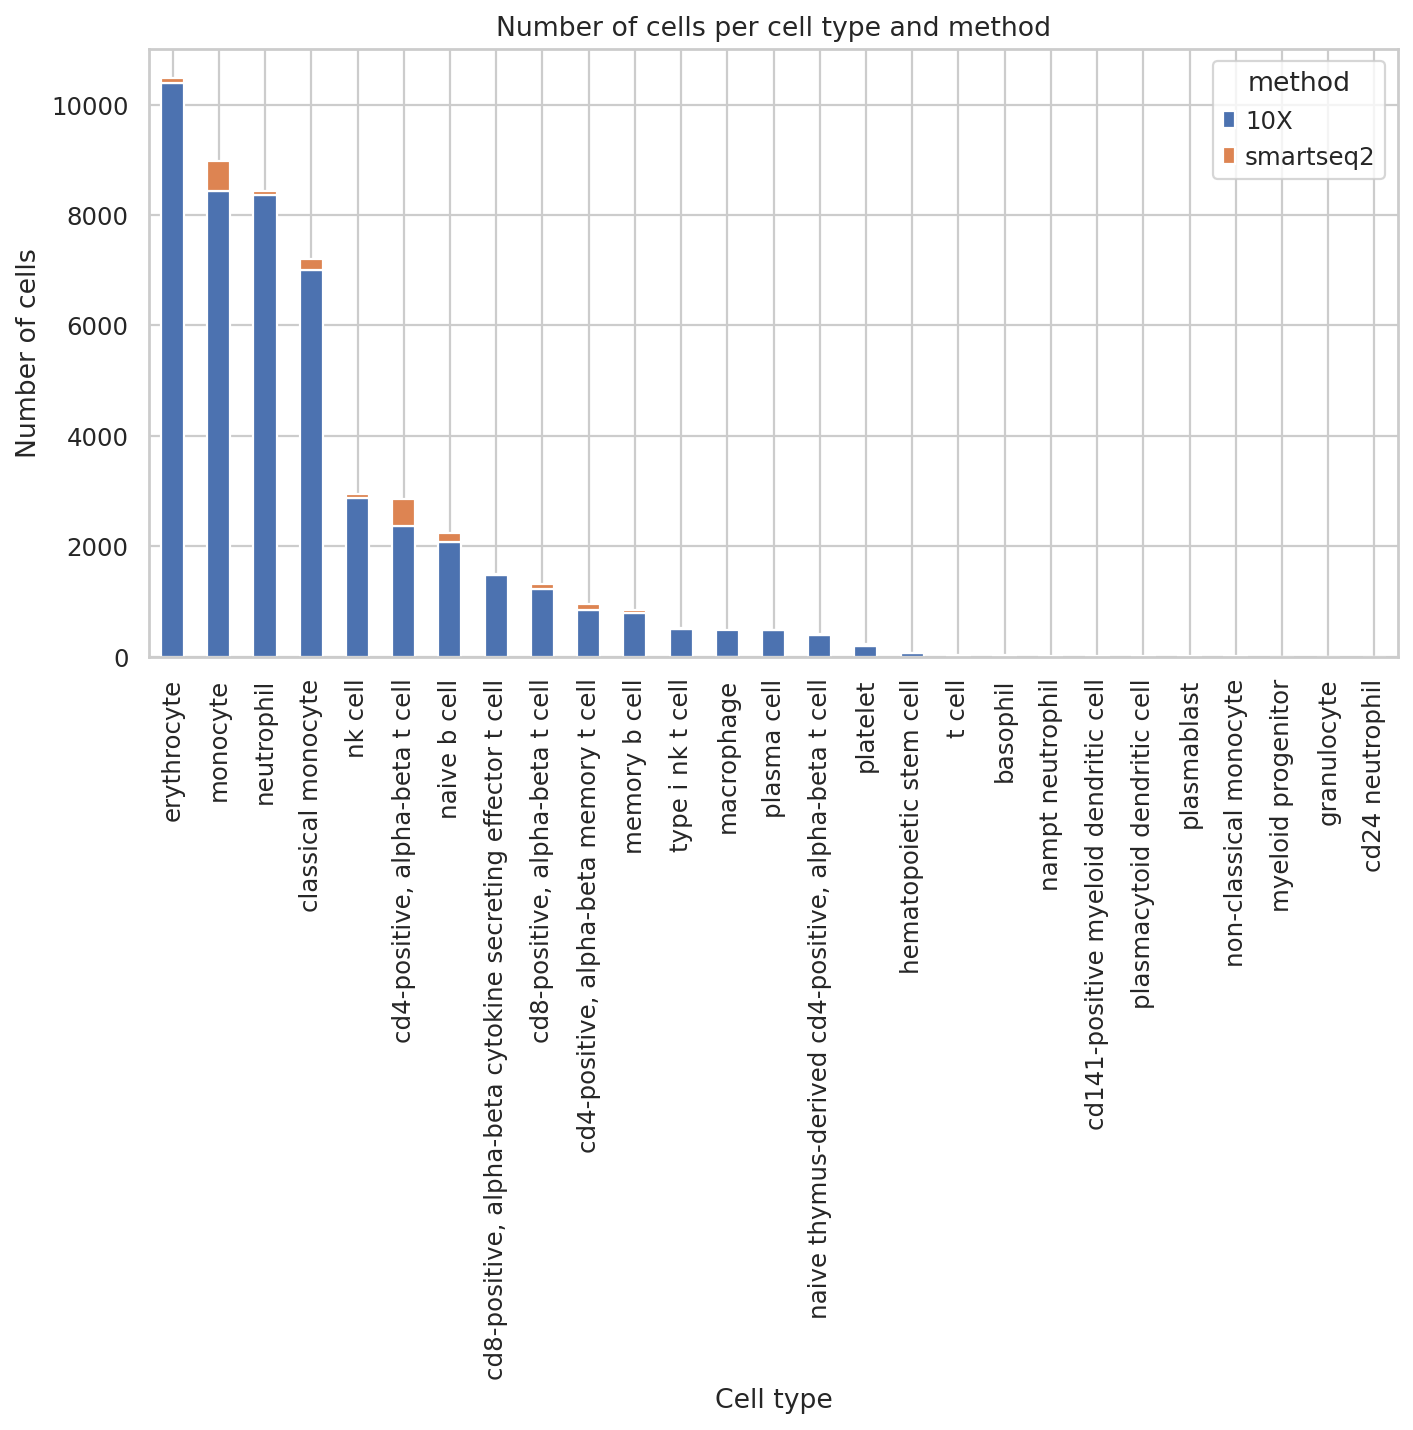

In [33]:
# for each cell type show number of cells with each method and amke barplot
# mae plot wider
import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))
blood[['cell_ontology_class', 'method']].value_counts().unstack().plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Number of cells per cell type and method')
plt.ylabel('Number of cells')
plt.xlabel('Cell type')

A peripheral blood mononuclear cell (PBMC) is any peripheral blood cell having a round nucleus. These cells consist of lymphocytes (T cells, B cells, NK cells) and monocytes, whereas erythrocytes and platelets have no nuclei, and granulocytes (neutrophils, basophils, and eosinophils) have multi-lobed nuclei.

In [ ]:
# make dataframe of counts of method by organ tissue
method_counts = adata.obs.groupby(['method', 'organ_tissue']).size().reset_index(name='counts')
method_counts.sort_values(by='counts', ascending=False, inplace=True)

In [ ]:
order_organs = method_counts['organ_tissue'].unique()

In [ ]:
import seaborn as sns
sns.set(style="whitegrid")

# make barplot of counts of method by organ tissue follow order_organs
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="counts", y="organ_tissue", hue="method", data=method_counts, order=order_organs)
plt.title('Counts of method by organ tissue')
plt.show()


In [ ]:
# total number of cells by method
adata.obs.groupby(['method']).size().reset_index(name='counts')

In [ ]:
# remove ".14" or anything after period for every value in gene ids ENSG00000023902.14 
adata.var.index = adata.var.index.str.split('.').str[0]

In [ ]:
adata.obs 

In [ ]:
ss2 = adata.obs[adata.obs["method"] == "smartseq2"]
print(ss2.shape)
# summarize number of ss2 files per donor 
ss2.groupby("donor").size()

In [ ]:
ss2.groupby("organ_tissue").size().sort_values(ascending=False)

In [ ]:
# filter adata object to just ss2 data and muscle tissue 
adata = adata[adata.obs["method"] == "smartseq2"]
adata = adata[adata.obs["organ_tissue"] == "Muscle"]
print(adata.shape)

In [ ]:
adata = adata[~adata.obs["free_annotation"].isin(["endothelial cell of artery", "erythrocyte", "mesothelial cell"]), :]       
print(adata.shape)       

In [ ]:
# use values in adata.obsm to plot the UMAP
sc.pl.umap(adata, color=["donor"], palette=["red", "grey", "blue"])

In [ ]:
sc.pl.umap(adata, color=["anatomical_information"])

In [ ]:
sc.pl.umap(adata, color = "cell_ontology_class", palette = "tab20")

In [ ]:
sc.pl.umap(adata, color = "compartment")

In [ ]:
sc.pl.pca(adata, color='compartment')

In [ ]:
adata.obs.groupby(["cell_ontology_class", "compartment"]).size().sort_values(ascending=False)

In [ ]:
# sumamrize number of samples across donors and organs and filter out zero entries 
donors_summ = ss2.groupby(["donor", "organ_tissue"]).size().unstack().fillna(0)
# remove rows that have all zeros
donors_summ = donors_summ.loc[(donors_summ != 0).any(axis=1)]

In [ ]:
ss2["bam_file_name"] = ss2.index

In [ ]:
# Assuming 'ss2' is your DataFrame
ss2.loc[ss2["donor"] == "TSP1", "donor_id"] = "Pilot1"
ss2.loc[ss2["donor"] == "TSP2", "donor_id"] = "Pilot2"
ss2.loc[ss2["donor"] == "TSP3", "donor_id"] = "Pilot3"
ss2.loc[ss2["donor"] == "TSP4", "donor_id"] = "Pilot4"
ss2.loc[ss2["donor"] == "TSP5", "donor_id"] = "Pilot5"
ss2.loc[ss2["donor"] == "TSP6", "donor_id"] = "Pilot6"
ss2.loc[ss2["donor"] == "TSP7", "donor_id"] = "Pilot7"
ss2.loc[ss2["donor"] == "TSP8", "donor_id"] = "Pilot8"
ss2.loc[ss2["donor"] == "TSP9", "donor_id"] = "Pilot9"
ss2.loc[ss2["donor"] == "TSP10", "donor_id"] = "Pilot10"
ss2.loc[ss2["donor"] == "TSP11", "donor_id"] = "Pilot11"
ss2.loc[ss2["donor"] == "TSP12", "donor_id"] = "Pilot12"
ss2.loc[ss2["donor"] == "TSP13", "donor_id"] = "Pilot13"
ss2.loc[ss2["donor"] == "TSP14", "donor_id"] = "Pilot14"
ss2.loc[ss2["donor"] == "TSP15", "donor_id"] = "Pilot15"

In [ ]:
ss2[ss2["bam_file_name"] == "TSP2_LymphNode_Inguinal_SS2_B113694_B133052_ImmuneLinNeg_I10_S202"]

In [ ]:
ss2[ss2["organ_tissue"] == "Muscle"].donor.unique()

In [ ]:
# write SS2 to file saved as "tabula_sapiens_ss2_metadata.csv"
ss2.to_csv("/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/tabula_sapiens_ss2_metadata.csv", index=False)

In [ ]:
ss2[ss2["donor"] == "TSP1"]

In [ ]:
for org in ss2.organ_tissue.unique():
    print(org)

In [ ]:
# save ss2 file as text file for saving BAM files 
ss2_short = ss2[["donor", "organ_tissue", "bam_file_name", "donor_id"]]
print(ss2_short.head())
ss2_short.to_csv("/commons/projects/CZI-tabula-sapiens/SS2_data_processing/ss2_samples.txt", sep="\t", index=False, header=False)

In [ ]:
ss2

In [ ]:
# subset adata to just the cells in ss2 
adata.obsm["X_umap"]

# turn adata.obsm["X_umap"] into dataframe 
umap = pd.DataFrame(adata.obsm["X_umap"])
umap["cell_id"] = adata.obs.index
umap.head()

In [ ]:
umap = umap[umap.cell_id.isin(ss2.index)]
umap.head()

In [ ]:
LN = ss2[ss2["organ_tissue"] == "Muscle"]
umap = umap[umap.cell_id.isin(LN.index)]
umap.head()

In [ ]:
# change umap columns to UMAP1, UMAP2
umap.columns = ['UMAP1', 'UMAP2', 'cell_id']

In [ ]:
ss2["cell_id"] = ss2.index 
# merge ss2 and umap 
umap = ss2.merge(umap)

In [ ]:
# assign unique colors to free_annotation column and use those to make scatterplot
annotations = umap['free_annotation'].unique()

# Then we generate a list of colors for these labels.
colors = plt.cm.tab20(np.linspace(0, 1, len(annotations)))

# Now we create a dictionary that maps annotations to colors.
annotation_to_color = dict(zip(annotations, colors))

# We apply this mapping to the 'free_annotation' column to get the actual color values.
umap['color'] = umap['free_annotation'].map(annotation_to_color)

umap

In [ ]:
umap.cell_ontology_class.value_counts().head(20)

In [ ]:
# Create a list of patches to use as handles in the legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=annotation_to_color[annotation], label=annotation) for annotation in annotations]

# plt scatter plot of umap1 vs umap2 and color by free_annotation
plt.figure(figsize=(7,7))
plt.scatter(umap["UMAP1"], umap["UMAP2"], c=umap["color"], cmap="tab20", alpha=0.5)
plt.title("Lymph Node")
plt.show()

In [ ]:
plt.scatter(umap["UMAP1"], umap["UMAP2"], c=umap["color"], cmap="tab20", alpha=0.5)

In [ ]:
# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

In [ ]:
plt.legend(handles=legend_handles, title='Annotations')


In [ ]:
adata

In [ ]:
# subset adata to just the cells in ss2 and muscle organ 
adata = adata[adata.obs.index.isin(ss2.index)]
adata = adata[adata.obs.index.isin(LN.index)]
adata

In [ ]:
sc.pl.highest_expr_genes(adata, n_top=20, )

In [ ]:
sc.pp.filter_cells(adata, min_genes=200) # remove cells that have less than 200 genes expressed
sc.pp.filter_genes(adata, min_cells=5) # remove genes that are expressed in less than 3 cells
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
# remove cells that have more than 5% mitochondrial genes
adata

In [ ]:
# With pp.calculate_qc_metrics, we can compute many metrics very efficiently.
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts'],
             jitter=0.4, multi_panel=True)

In [ ]:
print("Remove cells with very high values for total_counts, possible doublets")

print('Started with: \n', adata)
print_separator()
adata = adata[adata.obs.total_counts < 10000, :]
print('Finished with: \n', adata)

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

#sc.pl.highly_variable_genes(adata)

adata.raw = adata
adata = adata[:, adata.var.highly_variable]

#Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed. Scale the data to unit variance.
sc.pp.regress_out(adata, ['total_counts'])

#Scale each gene to unit variance. Clip values exceeding standard deviation 10.
sc.pp.scale(adata, max_value=10)

In [ ]:
adata.obs.head()

In [ ]:
# remove these cell types from adata: endothelial cell of artery, erythrocyte, mesothelial cell             
adata = adata[~adata.obs["free_annotation"].isin(["endothelial cell of artery", "erythrocyte", "mesothelial cell"]), :]              

In [ ]:
print("The number of cells and genes going into PCA is: " + str(adata.shape))
sc.tl.pca(adata, svd_solver='arpack')

In [ ]:
sc.pl.pca(adata, color='cell_ontology_class')

In [ ]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata)

In [ ]:
sc.pl.umap(adata, color=['leiden'])

In [ ]:
sc.pl.umap(adata, color=['cell_ontology_class'])

In [ ]:
# plot adata umap color by TSP by donor
# use colors grey, blue and red for TSP1, TSP2, TSP4
sc.pl.umap(adata, color=['donor'], palette=["grey", "blue", "red"])

In [ ]:
sc.pl.umap(adata, color=['anatomical_information'])

In [ ]:
# calculate total counts per cell across each donor 
adata.obs.groupby("donor").total_counts.sum()

In [ ]:
adata.obs